# Athlete Recovery & Biometric Performance Dataset - Exploratory Data Analysis (EDA)

## Introduction

Welcome to the **Exploratory Data Analysis** of the **Athlete Recovery & Biometric Performance Dataset**.

This dataset contains longitudinal data for approximately **300 athletes** over **28 days**, capturing rich information about their training, lifestyle, physiological markers, and recovery. The main target variable is **`Recovery_Score`** (0-100), which reflects how well an athlete recovered on a given day.

**Objectives of this EDA:**
- Understand the structure and quality of the dataset
- Explore distributions of key variables
- Analyze relationships between training, sleep, biometrics (especially HRV), and recovery
- Identify patterns across time, athletes, and sport types
- Extract actionable insights for sports science and machine learning

This analysis serves as a foundation for building predictive models, personalized recovery systems, and data-driven training recommendations.

---

## 1. Importing Libraries and Data loading

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sarveshchhetri/athlete-recovery-and-biometric-performance-dataset/athlete_recovery_synthetic.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sarveshchhetri/athlete-recovery-and-biometric-performance-dataset/athlete_recovery_synthetic.csv')
print(f"Dataset Shape: {df.shape}")
df.head(5)

Dataset Shape: (8379, 19)


,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1
1,1000,2,2,1,28,Male,Team Sport,Cardio,71,7.0,7.3,258,Low,55,79,5.9,4.0,5.8,63.7
2,1000,3,3,1,28,Male,Team Sport,HIIT,45,7.3,7.7,214,Medium,57,77,5.1,4.0,5.6,71.0
3,1000,4,4,1,28,Male,Team Sport,Cardio,86,7.5,7.9,228,High,61,71,3.0,6.2,2.7,37.2
4,1000,5,5,1,28,Male,Team Sport,HIIT,28,9.2,6.7,0,High,64,62,3.3,7.4,1.1,12.3


## 2. Dataset Overview and data quality

In [4]:
print("=== Basic Information ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Number of Unique Athletes ===")
print(df['Athlete_ID'].nunique())

=== Basic Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Athlete_ID             8379 non-null   int64  
 1   Day                    8379 non-null   int64  
 2   Day_of_Week            8379 non-null   int64  
 3   Week                   8379 non-null   int64  
 4   Age                    8379 non-null   int64  
 5   Gender                 8379 non-null   object 
 6   Sport_Type             8379 non-null   object 
 7   Training_Type          8379 non-null   object 
 8   Training_Duration_Min  8379 non-null   int64  
 9   Training_Intensity     8378 non-null   float64
 10  Sleep_Duration_Hours   7775 non-null   float64
 11  Caffeine_Intake_mg     8379 non-null   int64  
 12  Stress_Level           8379 non-null   object 
 13  Resting_Heart_Rate     8379 non-null   int64  
 14  HRV_ms                 8379 no

**Observations:**

- Total records and features
- Missing values (mainly in Sleep_Duration_Hours)
- Data types and memory usage

## 3. Descriptive Statistics

In [5]:
df.describe()

,Athlete_ID,Day,Day_of_Week,Week,Age,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
count,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8378.000000,7775.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000
mean,1149.458647,14.497076,3.998329,2.499821,25.860962,52.789712,6.211506,7.498842,185.348132,57.202888,74.126507,5.177109,5.161953,3.273087,49.061356
std,86.631832,8.078044,2.000417,1.117941,4.531092,21.357704,2.368960,0.693790,112.850208,5.790991,13.981632,1.210072,2.127583,1.679100,27.926347
min,1000.000000,1.000000,1.000000,1.000000,18.000000,10.000000,1.000000,5.000000,0.000000,38.000000,22.000000,1.000000,1.000000,1.000000,0.000000
25%,1074.000000,8.000000,2.000000,2.000000,23.000000,36.000000,4.900000,7.000000,126.000000,53.000000,64.000000,4.400000,3.600000,2.000000,27.800000
50%,1149.000000,14.000000,4.000000,2.000000,26.000000,56.000000,6.600000,7.500000,212.000000,58.000000,74.000000,5.200000,5.200000,3.100000,48.900000
75%,1224.000000,21.000000,6.000000,3.000000,28.000000,69.000000,7.900000,8.000000,268.000000,61.000000,84.000000,6.000000,6.700000,4.300000,69.900000
max,1299.000000,28.000000,7.000000,4.000000,41.000000,115.000000,10.000000,9.500000,400.000000,81.000000,115.000000,9.500000,10.000000,10.000000,100.000000


**Summary:**
Key statistics for numerical columns including mean, standard deviation, min, and max values.

## 4. Univariate Analysis

### 4.1 Target Variable: Recovery score

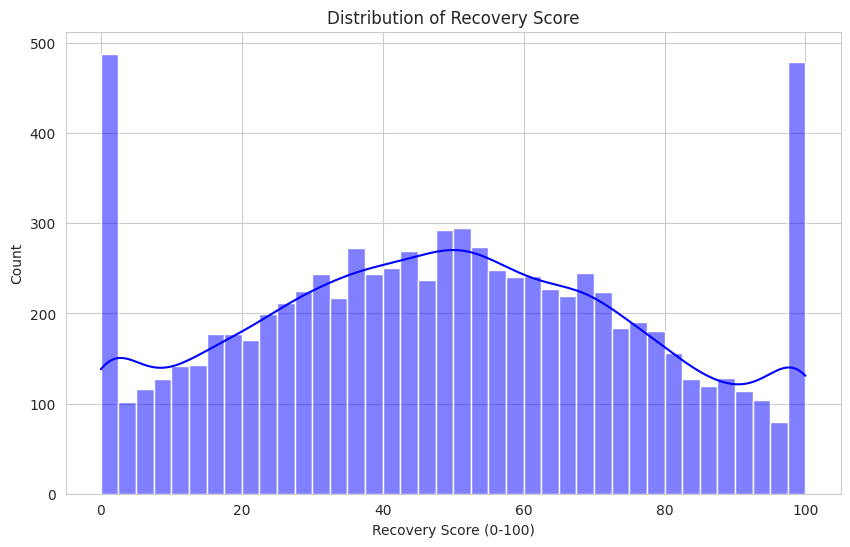

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Recovery_Score'], kde=True, bins=40, color='blue')
plt.title('Distribution of Recovery Score')
plt.xlabel('Recovery Score (0-100)')
plt.ylabel('Count')
plt.show()

### 4.2 Importance feature distributions

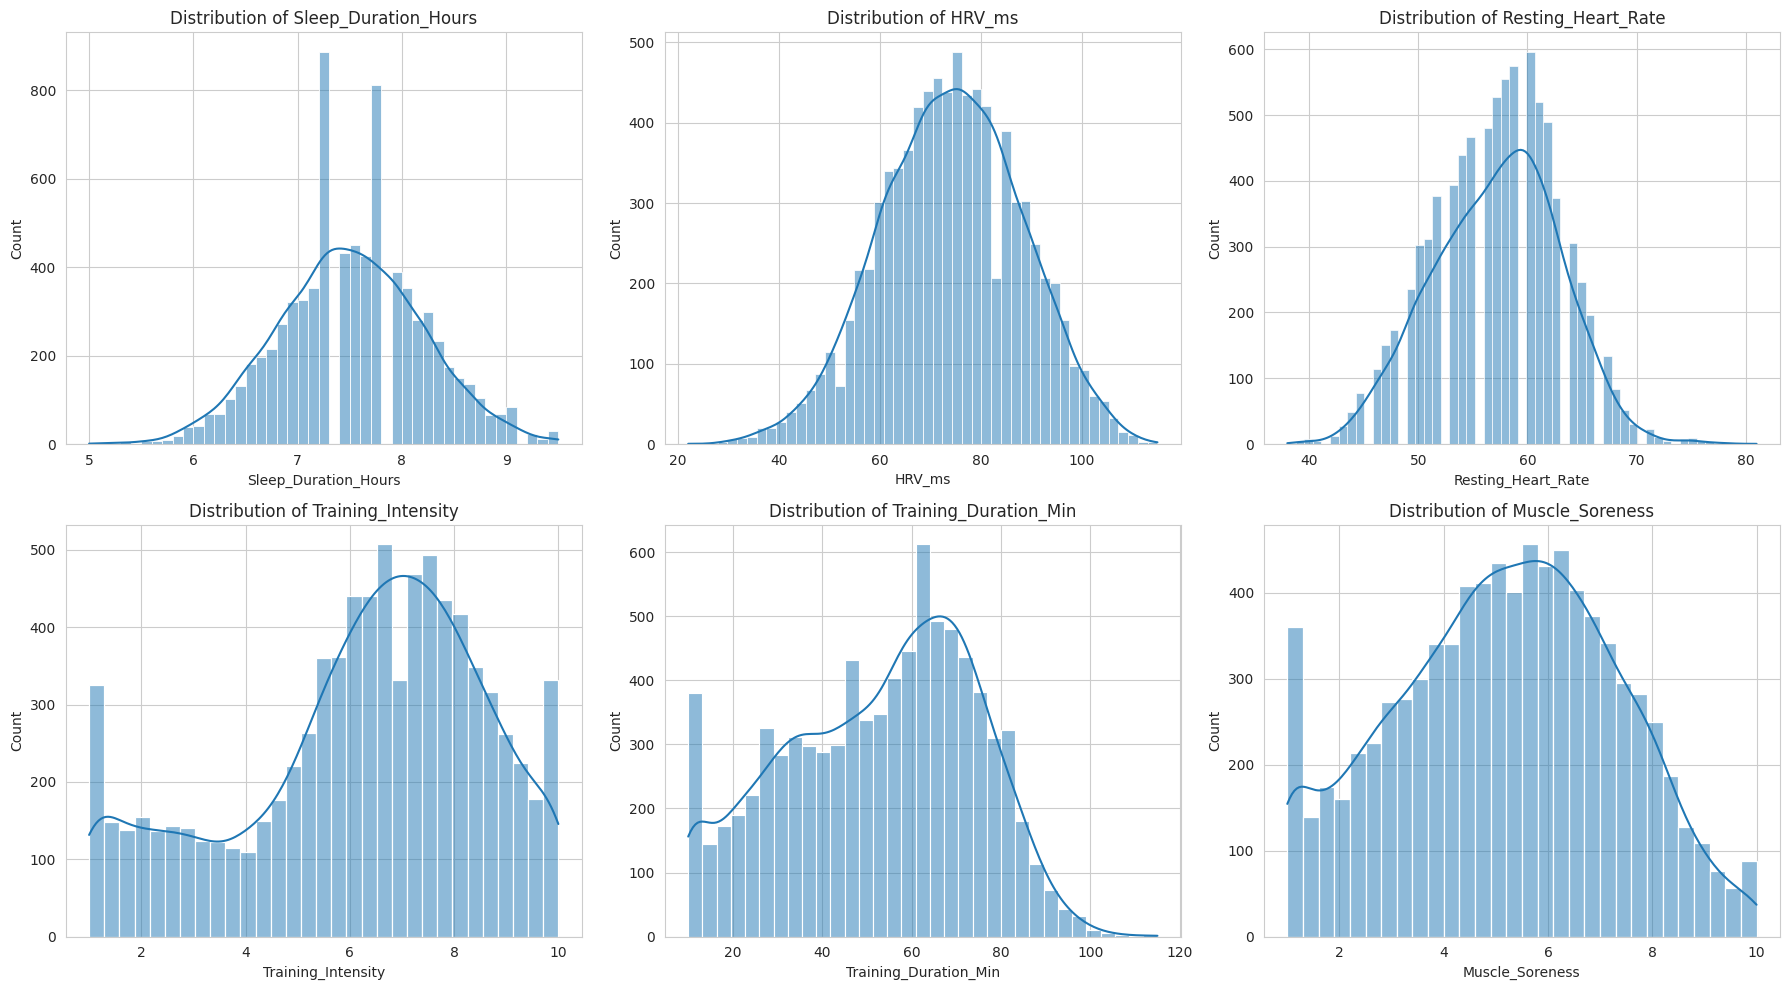

In [7]:
key_features = ['Sleep_Duration_Hours', 'HRV_ms', 'Resting_Heart_Rate', 
                'Training_Intensity', 'Training_Duration_Min', 'Muscle_Soreness']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(key_features):
    sns.histplot(df[col], kde=True, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'Distribution of {col}')
plt.tight_layout()

## 5. Correlation analysis

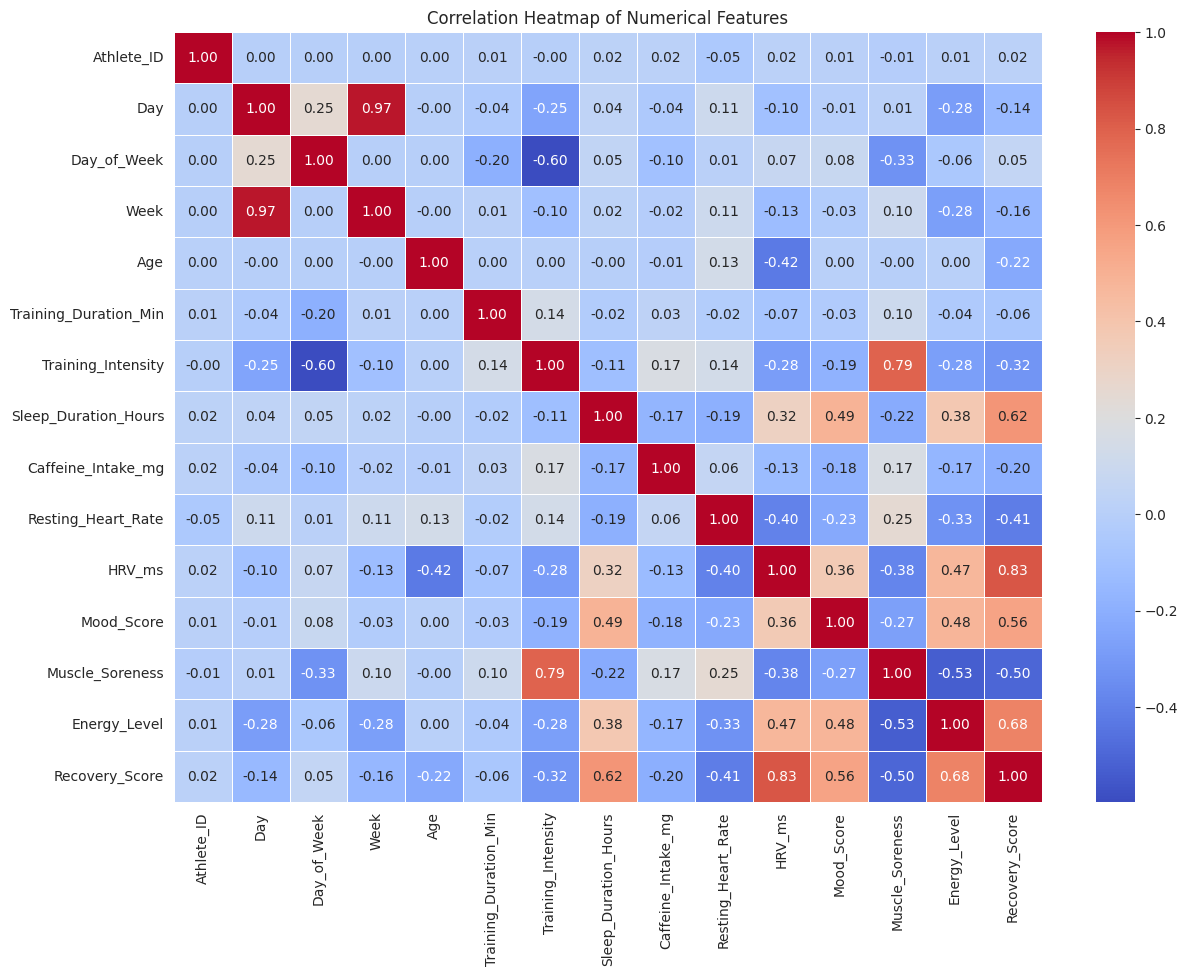

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 6. Relationship with recovery score

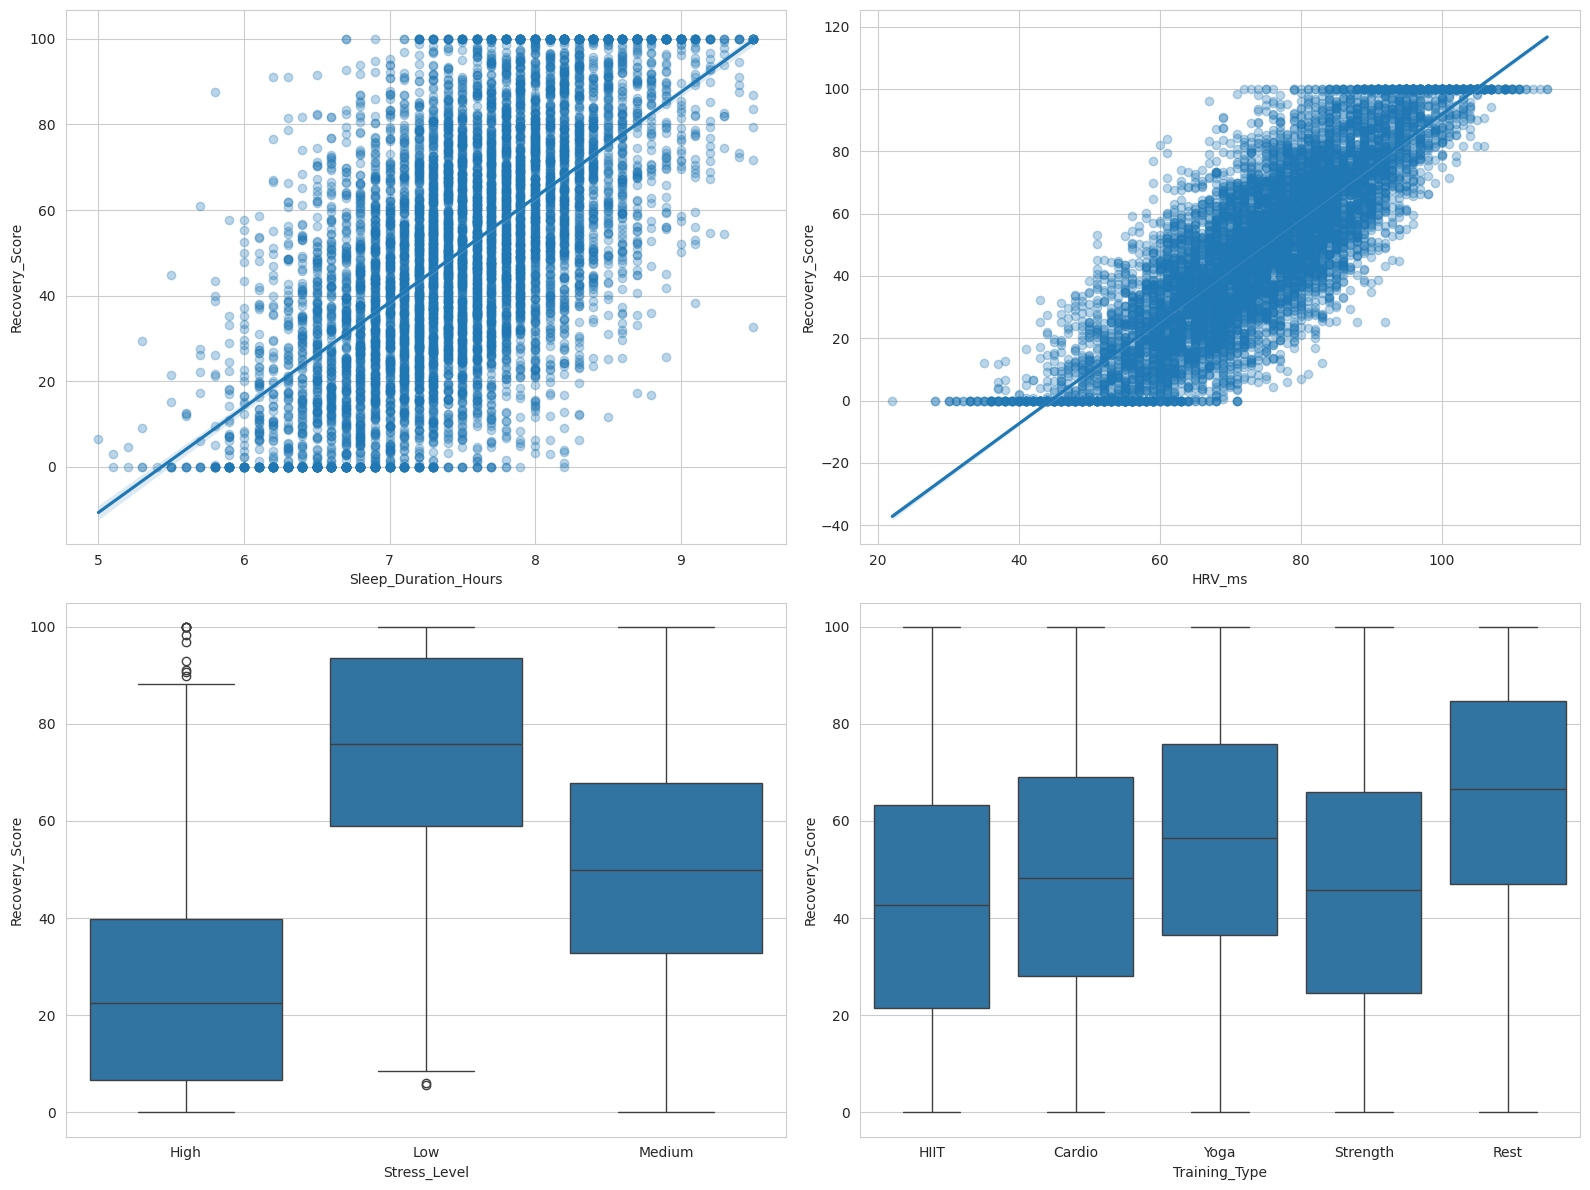

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.regplot(data=df, x='Sleep_Duration_Hours', y='Recovery_Score', ax=axes[0,0], scatter_kws={'alpha':0.3})
sns.regplot(data=df, x='HRV_ms', y='Recovery_Score', ax=axes[0,1], scatter_kws={'alpha':0.3})
sns.boxplot(data=df, x='Stress_Level', y='Recovery_Score', ax=axes[1,0])
sns.boxplot(data=df, x='Training_Type', y='Recovery_Score', ax=axes[1,1])
plt.tight_layout()
plt.show()

## 7. Grouped Analysis

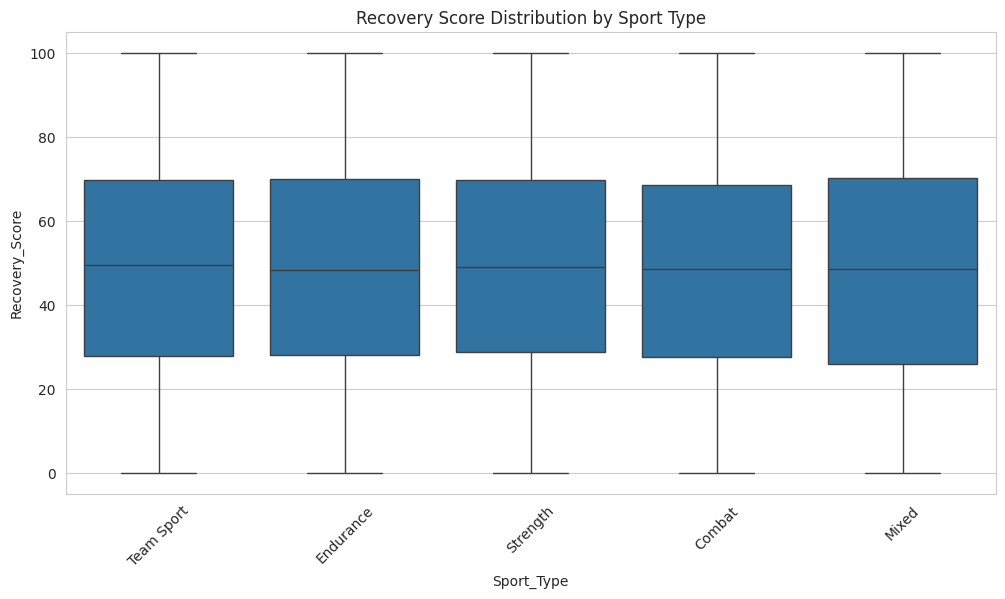

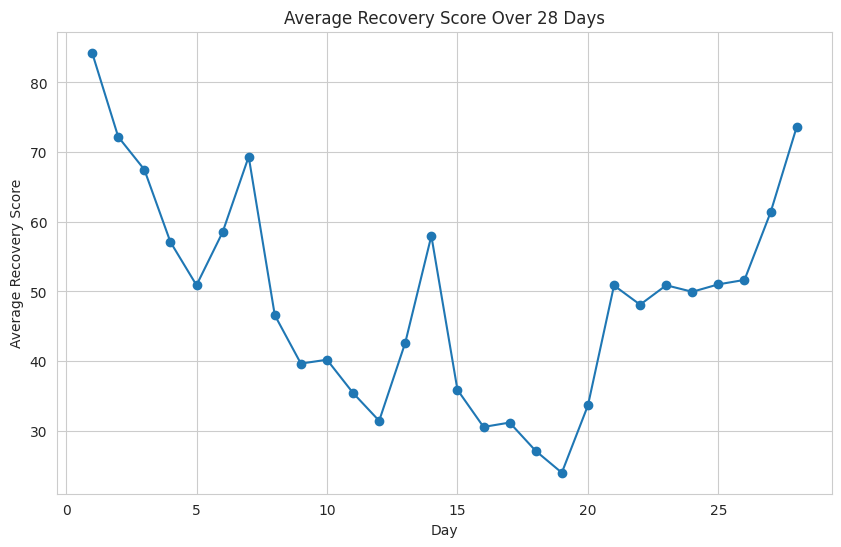

In [10]:
# Recovery by Sport Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Sport_Type', y='Recovery_Score')
plt.xticks(rotation=45)
plt.title('Recovery Score Distribution by Sport Type')
plt.show()

# Recovery Trend over Days
daily_recovery = df.groupby('Day')['Recovery_Score'].mean()
daily_recovery.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Average Recovery Score Over 28 Days')
plt.xlabel('Day')
plt.ylabel('Average Recovery Score')
plt.grid(True)
plt.show()

## Conclusion and Key insights
**Major Findings from the EDA:**

1. Sleep Duration has one of the strongest positive correlations with Recovery Score.
2. HRV (Heart Rate Variability) is a powerful objective indicator of recovery.
3. High Stress Levels significantly lower recovery scores.
4. Different Training Types (HIIT, Strength, Yoga, Rest) show distinct recovery patterns.
5. There is noticeable individual variation between athletes — supporting the need for personalized models.
6. Missing values are limited and easy to handle (mostly in sleep).

**Actionable Sports Science Insights:**

- Prioritizing quality sleep and stress management can dramatically improve recovery.
- Monitoring HRV alongside subjective feelings provides a robust recovery picture.
- Recovery is not one-size-fits-all — individual athlete modeling is highly recommended.

---

## Next Steps

- Feature Engineering (Training Load, Rolling Statistics, Sleep Deficit, etc.)
- Advanced Modeling (XGBoost, LightGBM, Time Series models)
- Personalized Athlete-Level Prediction
- Building an interactive Recovery Dashboard

---

**Thank you for exploring this dataset!**
This EDA provides a strong foundation for further analysis and modeling. Feel free to fork this notebook, experiment with the data, and share your findings.

*If you found this helpful, please consider upvoting the dataset and notebook! 🚀*